In [1]:
%load_ext autoreload
%autoreload 2
import sys
ProjDIR = "/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/" # Change to your project directory
sys.path.insert(1, f'{ProjDIR}/src/')
from CellType_PSY import *
#import scanpy as sc
HGNC, ENSID2Entrez, GeneSymbol2Entrez, Entrez2Symbol = LoadGeneINFO()

try:
    os.chdir(f"{ProjDIR}/notebooks/")
    print(f"Current working directory: {os.getcwd()}")
except FileNotFoundError as e:
    print(f"Error: Could not change directory - {e}")
except Exception as e:
    print(f"Unexpected error: {e}")

Current working directory: /home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/notebooks


In [2]:
HCT_Z2_MAT_HCT = pd.read_csv("/home/jw3514/Work/CellType_Psy/dat/HumanCTExpressionMats/Human.Cluster.Log2Mean.Z1clip5.Z2.clip3.Dec30.csv", index_col=0)
HCT_Z2_MAT_HCT.columns = HCT_Z2_MAT_HCT.columns.astype(int)

# SCZ

In [5]:
GeneDF = pd.read_excel("../dat/41586_2022_4556_MOESM3_ESM.xlsx",
                    sheet_name="Table S5 - Gene Results")
ExAC_pLI = pd.read_csv("/home/jw3514/Work/Resources/gnomad.v2.1.1.lof_metrics.by_gene.txt", sep="\t",
                      index_col="gene")

In [6]:
Ncase = 24248
Nctrl = 97322

In [7]:
GeneDF.head(2)

,Gene Symbol,Gene Name,Case PTV,Ctrl PTV,Case mis3,Ctrl mis3,Case mis2,Ctrl mis2,P ca/co (Class 1),P ca/co (Class 2),...,Case syn,Ctrl syn,P ca/co (syn),"P meta, no gnomAD","Case/Ctrl PTV, no gnomAD","Case/Ctrl mis3, no gnomAD","Case/Ctrl mis2, no gnomAD","P ca/co (Class I), no gnomAD","P ca/co (Class II), no gnomAD","P ca/co (comb), no gnomAD"
0,SETD1A,SET domain containing 1A,15.0,3.0,3.0,4.0,11,10,3.600000e-07,0.000588,...,92.0,426.0,0.201,5.890000e-10,15/3,3/3,11/4,0.000025,0.00235,0.000001
1,CUL1,Cullin 1,8.0,1.0,2.0,0.0,7,16,1.010000e-05,0.261000,...,37.0,154.0,0.925,3.550000e-07,8/1,2/0,7/10,0.000448,0.56700,0.000395


#### Mutation Type Enrichment

In [8]:
pLI_gt_0 = GeneDF[GeneDF["pLI"]>0.9]
pLI_lt_0 = GeneDF[GeneDF["pLI"]<=0.9]
print(pLI_gt_0.shape, pLI_lt_0.shape)
for DF, name in zip([GeneDF, pLI_gt_0, pLI_lt_0], ["All", "pLI>0.9", "pLI<=0.9"]):
    print(name)
    Case_LGD = DF["Case PTV"].sum()
    Case_Mis3 = DF["Case mis3"].sum() 
    Case_Mis2 = DF["Case mis2"].sum()

    Ctrl_LGD = DF["Ctrl PTV"].sum()
    Ctrl_Mis3 = DF["Ctrl mis3"].sum()
    Ctrl_Mis2 = DF["Ctrl mis2"].sum()
    # Calculate odds ratio for each mutation type
    LGD_OR = (Case_LGD * (Nctrl - Ctrl_LGD)) / (Ctrl_LGD * (Ncase - Case_LGD))
    Mis3_OR = (Case_Mis3 * (Nctrl - Ctrl_Mis3)) / (Ctrl_Mis3 * (Ncase - Case_Mis3))
    Mis2_OR = (Case_Mis2 * (Nctrl - Ctrl_Mis2)) / (Ctrl_Mis2 * (Ncase - Case_Mis2))

    print(f"LGD odds ratio: {LGD_OR:.2f}")
    print(f"Mis3 odds ratio: {Mis3_OR:.2f}")
    print(f"Mis2 odds ratio: {Mis2_OR:.2f}")



KeyError: 'pLI'

In [101]:
pLI_gt_0 = GeneDF[GeneDF["pLI"]>0.9]
pLI_lt_0 = GeneDF[GeneDF["pLI"]<=0.9]
print(pLI_gt_0.shape, pLI_lt_0.shape)
for DF, name in zip([GeneDF, pLI_gt_0, pLI_lt_0], ["All", "pLI>0.9", "pLI<=0.9"]):
    print(name)
    Case_LGD = DF["Case PTV"].sum()
    Case_Mis3 = DF["Case mis3"].sum() 
    Case_Mis2 = DF["Case mis2"].sum()

    Ctrl_LGD = DF["Ctrl PTV"].sum()
    Ctrl_Mis3 = DF["Ctrl mis3"].sum()
    Ctrl_Mis2 = DF["Ctrl mis2"].sum()
    # Calculate PPV instead, define as fraction of mutation leading to disorder
    LGD_PPV = (Case_LGD - Ctrl_LGD / Nctrl * Ncase) / Case_LGD
    Mis3_PPV = (Case_Mis3 - Ctrl_Mis3 / Nctrl * Ncase) / Case_Mis3
    Mis2_PPV = (Case_Mis2 - Ctrl_Mis2 / Nctrl * Ncase) / Case_Mis2

    print(f"LGD PPV: {LGD_PPV:.2f}")
    print(f"Mis3 PPV: {Mis3_PPV:.2f}")
    print(f"Mis2 PPV: {Mis2_PPV:.2f}")

(2862, 40) (13963, 40)
All
LGD PPV: 0.08
Mis3 PPV: 0.12
Mis2 PPV: 0.11
pLI>0.9
LGD PPV: 0.33
Mis3 PPV: 0.27
Mis2 PPV: 0.12
pLI<=0.9
LGD PPV: 0.06
Mis3 PPV: -0.02
Mis2 PPV: 0.09


#### Modify Mutation Counts

In [9]:
def oddsratio(NcaseMut, NctrlMut, dnvCount, Ncase = 24248, Nctrl=97322):
    if dnvCount!=dnvCount:
        dnvCount = 0
    NcaseMut += 1 # add pseudo count to prevent inf 
    NctrlMut += 1
    AD = (NcaseMut) * (Nctrl-NctrlMut) 
    BC = (NctrlMut) * (Ncase-NcaseMut)
    return AD/BC + dnvCount

def Penetrance(NcaseMut, NctrlMut, Ncase = 24248, Nctrl=97322, prevelence=0.45/100):
    NcaseMut += 1
    NctrlMut += 1
    Ntotal_ =  Ncase/prevelence
    Nctrl_ = Ntotal_ - Ncase
    NctrlMut_ = Nctrl_*(NctrlMut/Nctrl)
    #print(Nctrl_, NctrlMut_)
    p = NcaseMut/(NcaseMut+NctrlMut_)
    return p

In [10]:
Ncase = 24248
Nctrl = 97322

In [11]:
print(Penetrance(15, 3))
print(Penetrance(8, 1))
print(Penetrance(12, 1))
print(Penetrance(129, 466))

0.06766125880046411
0.07548052771054478
0.1054886128420013
0.005025102756081459


In [12]:
print(oddsratio(15, 3, 0))
print(oddsratio(8, 1, 0))
print(oddsratio(12, 1, 0))

16.064377682403432
18.067577045257643
26.101918712605734


In [86]:
# Effective mutation count in case  
def ModifyMutCount(CaseCount, ContCount, dnvCount, CaseN=24248, ContN=97322):
    if isinstance(dnvCount, float) and np.isnan(dnvCount):
        dnvCount = 0
    return max(CaseCount - ContCount / ContN * CaseN + dnvCount, 0)

for i, row in GeneDF.iterrows():
    symbol = row["Gene Symbol"]
    print(i, symbol)
    
    try:
        GeneDF.loc[i, "Entrez"] = int(GeneSymbol2Entrez[symbol])
    except:
        GeneDF.loc[i, "Entrez"] = None
        
    try:
        GeneDF.loc[i, "pLI"] = ExAC_pLI.loc[symbol, "pLI"]
    except:
        GeneDF.loc[i, "pLI"] = 0
        
    case_ptv = float(row["Case PTV"]) if not pd.isna(row["Case PTV"]) else 0
    ctrl_ptv = float(row["Ctrl PTV"]) if not pd.isna(row["Ctrl PTV"]) else 0
    case_mis3 = float(row["Case mis3"]) if not pd.isna(row["Case mis3"]) else 0 
    ctrl_mis3 = float(row["Ctrl mis3"]) if not pd.isna(row["Ctrl mis3"]) else 0
    case_mis2 = float(row["Case mis2"]) if not pd.isna(row["Case mis2"]) else 0
    ctrl_mis2 = float(row["Ctrl mis2"]) if not pd.isna(row["Ctrl mis2"]) else 0
    
    dnv_ptv = float(row["De novo PTV"]) if not pd.isna(row["De novo PTV"]) else 0
    dnv_mis3 = float(row["De novo mis3"]) if not pd.isna(row["De novo mis3"]) else 0
    dnv_mis2 = float(row["De novo mis2"]) if not pd.isna(row["De novo mis2"]) else 0

    GeneDF.loc[i, "nLGD"] = ModifyMutCount(case_ptv, ctrl_ptv, 0)
    GeneDF.loc[i, "nMis3"] = ModifyMutCount(case_mis3, ctrl_mis3, 0)
    GeneDF.loc[i, "nMis2"] = ModifyMutCount(case_mis2, ctrl_mis2, 0)

    GeneDF.loc[i, "LGD_OR"] = oddsratio(case_ptv, ctrl_ptv, dnv_ptv)
    GeneDF.loc[i, "Mis3_OR"] = oddsratio(case_mis3, ctrl_mis3, dnv_mis3)
    GeneDF.loc[i, "Mis2_OR"] = oddsratio(case_mis2, ctrl_mis2, dnv_mis2)
    
    GeneDF.loc[i, "LGD_pen"] = Penetrance(case_ptv, ctrl_ptv)
    GeneDF.loc[i, "Mis3_pen"] = Penetrance(case_mis3, ctrl_mis3)
    GeneDF.loc[i, "Mis2_pen"] = Penetrance(case_mis2, ctrl_mis2)
    
GeneDF = GeneDF.dropna(subset=["Entrez"])
GeneDF = GeneDF.set_index("Entrez")
GeneDF = GeneDF[GeneDF.index.isin(HCT_Z2_MAT_HCT.index.values)]
GeneDF.to_csv("../dat/SCZ.ALLGENE.MutCountModified.csv")
GeneDF.shape

0 SETD1A
1 CUL1
2 XPO7
3 TRIO
4 CACNA1G
5 SP4
6 GRIA3
7 GRIN2A
8 HERC1
9 RB1CC1
10 HCN4
11 AKAP11
12 ZNF136
13 SRRM2
14 NR3C2
15 ZMYM2
16 FAM120A
17 SLF2
18 KDM6B
19 DNM3
20 ASH1L
21 STAG1
22 H1-4
23 PREP
24 MAGEC1
25 MAGI2
26 DAGLA
27 OR4P4
28 SLC22A11
29 ANKRD12
30 SV2A
31 EIF2S3
32 PCLO
33 SOBP
34 BSCL2
35 NR4A2
36 XKR6
37 ATP9A
38 FYN
39 CRAT
40 NPRL3
41 SCAF1
42 MPPED1
43 SLC34A2
44 ZNF318
45 CGREF1
46 POTEF
47 FABP7
48 TRAPPC10
49 PTGER1
50 PCNX3
51 HMGCR
52 CACNA2D1
53 SRPK1
54 OR2T8
55 ZMYND11
56 LMBR1L
57 KCNN3
58 SLITRK5
59 SLC25A43
60 S100P
61 ABHD13
62 RAB29
63 ZFC3H1
64 HERPUD2
65 PUM2
66 IPMK
67 MACF1
68 OTUD4
69 ADNP
70 CSPG5
71 UBE2E3
72 CRB1
73 ATP1A2
74 HMGB2
75 PROM1
76 TEFM
77 OMG
78 PATZ1
79 CNOT4
80 NRXN1
81 JAK3
82 SMARCA1
83 TSC22D1
84 CHAF1B
85 RYR2
86 CLPTM1
87 POLRMT
88 LZIC
89 BOD1L1
90 DCTN5
91 ZNF98
92 PSMA3
93 GAL3ST2
94 SMG7
95 NAMPT
96 HIVEP2
97 FAM71F2
98 SLX4IP
99 PCDHAC1
100 DYNC2H1
101 ATF2
102 QRICH1
103 FBXO16
104 CHD5
105 TUBB8
106 RBM4
107 CRIPA

(17057, 40)

In [13]:
GeneDF = pd.read_csv("../dat/SCZ.ALLGENE.MutCountModified.csv", index_col=0)

In [14]:
GeneDF.head(5)

,Gene Symbol,Gene Name,Case PTV,Ctrl PTV,Case mis3,Ctrl mis3,Case mis2,Ctrl mis2,P ca/co (Class 1),P ca/co (Class 2),...,pLI,nLGD,nMis3,nMis2,LGD_OR,Mis3_OR,Mis2_OR,LGD_pen,Mis3_pen,Mis2_pen
Entrez,,,,,,,,,,,,,,,,,,,,,
9739.0,SETD1A,SET domain containing 1A,15.0,3.0,3.0,4.0,11,10,3.600000e-07,0.000588,...,1.0,14.252543,2.003391,8.508477,19.064378,3.211252,4.380156,0.067661,0.014307,0.019408
8454.0,CUL1,Cullin 1,8.0,1.0,2.0,0.0,7,16,1.010000e-05,0.261000,...,1.0,7.750848,2.000000,3.013563,21.067577,12.042194,1.889051,0.075481,0.051619,0.008466
23039.0,XPO7,Exportin 7,12.0,1.0,1.0,1.0,10,32,2.000000e-08,0.539000,...,1.0,11.750848,0.750848,2.027126,27.101919,4.013858,1.338023,0.105489,0.017820,0.006011
7204.0,TRIO,Trio Rho guanine nucleotide exchange factor,18.0,16.0,0.0,0.0,24,102,2.080000e-06,0.910000,...,1.0,14.013563,0.000000,0.000000,6.488532,4.013734,0.974150,0.019874,0.017820,0.004384
8913.0,CACNA1G,"Calcium channel, voltage-dependent, T type, al...",10.0,13.0,8.0,4.0,55,134,3.160000e-06,0.031700,...,1.0,6.761020,7.003391,21.613592,3.154528,7.226808,2.666444,0.014055,0.031624,0.007470


In [15]:
def Aggregate_Gene_Weights_SCZ_Daly(MutFil, allen_mouse_genes, usepLI=False, Bmis=False, out=None, mode="MC", 
                                  lgd_weight=0.33, mis3_weight=0.27, mis2_weight=0.12):
    print("New")
    assert mode in ["OR", "MC", "ORMC"]
    print(mode)
    gene2MutN = {}
    for i, row in MutFil.iterrows():
        try:
            g = int(i)
            if g not in allen_mouse_genes:
                print(g, "not in Expression dataset")
                continue
        except:
            print(g, "Error converting Entrez ID")
        if usepLI:
            try:
                pLI = float(row["pLI"])
            except:
                print(g, "don't have pLI score on file, set to 0")
                pLI = 0.0
            if pLI >= 0.5:
                gene2MutN[g] = row["nLGD"] * 0.26 + row["nMis3"] * 0.25 + row["nMis2"] * 0.06  
            else:
                gene2MutN[g] = row["nLGD"] * 0.01 + row["nMis3"] * 0.01 + row["nMis2"] * 0 
        else:
            if mode == "OR":
                gene2MutN[g] = row["LGD_OR"] * lgd_weight + row["Mis3_OR"] * mis3_weight + row["Mis2_OR"] * mis2_weight
            elif mode == "MC":
                gene2MutN[g] = row["nLGD"] * lgd_weight + row["nMis3"] * mis3_weight + row["nMis2"] * mis2_weight
            ##elif mode == "ORMC":
            #    gene2MutN[g] = row["nLGD"] * lgd_weight + row["nMis3"] * mis3_weight + row["nMis2"] * mis2_weight
            #gene2MutN[g] = row["LGD_OR"] * 0.26 + row["Mis3_OR"] * 0.25 + row["nMis2_OR"] * 0.06
            #gene2MutN[g] = row["LGD_OR"] * 0.26 + row["Mis3_OR"] * 0.25 + row["nMis2_OR"] * 0.06
    if out != None:
        writer = csv.writer(open(out, 'wt'))
        for k,v in sorted(gene2MutN.items(), key=lambda x:x[1], reverse=True):
           writer.writerow([k,v]) 
    return gene2MutN


In [111]:
SCZ_61GW = Aggregate_Gene_Weights_SCZ_Daly(GeneDF.head(61), HCT_Z2_MAT_HCT.index.values, mode="MC")
OutDIR = "../dat/GeneWeights/"
Dict2Fil(SCZ_61GW, "{}/SCZ.top61.nopLI.MC.gw".format(OutDIR))

SCZ_61GW = Aggregate_Gene_Weights_SCZ_Daly(GeneDF.head(61), HCT_Z2_MAT_HCT.index.values, mode="OR")
OutDIR = "../dat/GeneWeights/"
Dict2Fil(SCZ_61GW, "{}/SCZ.top61.nopLI.OR.gw".format(OutDIR))

New
MC
New
OR


In [16]:
SCZ_61GW = Aggregate_Gene_Weights_SCZ_Daly(GeneDF.head(61), HCT_Z2_MAT_HCT.index.values, mode="MC", lgd_weight=1, mis3_weight=1, mis2_weight=1)
OutDIR = "../dat/GeneWeights/"
Dict2Fil(SCZ_61GW, "{}/SCZ.top61.nopLI.LGD_Dmis_SameWeight.gw".format(OutDIR))

New
MC


In [147]:
NLGDs = []
NDmis = []
Bias_CT = {}
for i, row in GeneDF.head(61).iterrows():
    try:
        gene = int(i)
        NLGDs.append(row["nLGD"])
        NDmis.append(row["nMis3"] + row["nMis2"])
        for CT in Neurons:
            CT_Idx = Anno[Anno["Supercluster"]==CT].index.values
            if CT not in Bias_CT:
                Bias_CT[CT] = []
            Bias_CT[CT].append(CT_Z2_MAT_HC.loc[gene, CT_Idx].mean())
    except:
        print(i, "not in exp data")

In [148]:
NLGDs = np.array(NLGDs)

In [149]:
print(len(NLGDs))
print(len(Bias_CT["Amygdala excitatory"]))

61
61


In [150]:
CT = "CGE interneuron"
CT = "MGE interneuron"
CT = "Thalamic excitatory"
_CT_Bias = np.array(Bias_CT[CT])
_CT_Bias > 0
NLGD_Pos = NLGDs[_CT_Bias > 0]
NLGD_Neg = NLGDs[_CT_Bias <= 0]
Total_G = len(NLGD_Pos) + len(NLGD_Neg)
print(len(NLGD_Pos), len(NLGD_Neg))
N_Mut_Pos = int(NLGD_Pos.sum())
Total_Mut = int(N_Mut_Pos + int(NLGD_Neg.sum()))
print(N_Mut_Pos, Total_Mut, N_Mut_Pos/Total_Mut / (len(NLGD_Pos)/Total_G))
print(scipy.stats.binom_test(N_Mut_Pos, Total_Mut, p=len(NLGD_Pos)/Total_G))

31 30
309 574 1.0592896481960212
0.1558059946647842


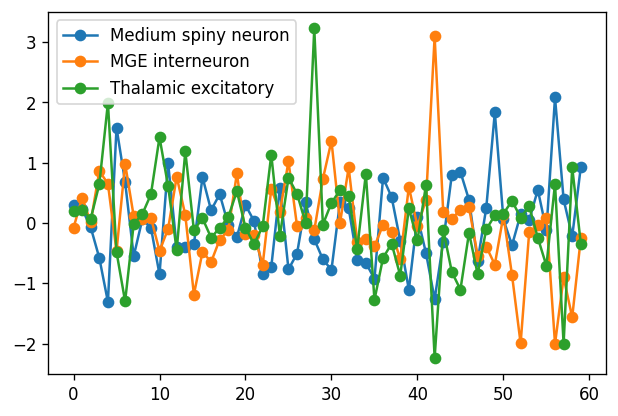

In [162]:
## Rank vs Bias
CT = "MGE interneuron"
CT = "Thalamic excitatory"
CT = "Medium spiny neuron"
CT_Idx = Anno[Anno["Supercluster"]==CT].index.values
Gene_Idx = GeneDF.head(60).index.values
dat = CT_Z2_MAT_HC.loc[Gene_Idx, CT_Idx].mean(axis=1)

fig, ax = plt.subplots(dpi=120)
CT = "Medium spiny neuron"
CT_Idx = Anno[Anno["Supercluster"]==CT].index.values
Gene_Idx = GeneDF.head(60).index.values
dat = CT_Z2_MAT_HC.loc[Gene_Idx, CT_Idx].mean(axis=1)
ax.plot(np.arange(len(Gene_Idx)), dat, marker="o", label=CT)

CT = "MGE interneuron"
CT_Idx = Anno[Anno["Supercluster"]==CT].index.values
Gene_Idx = GeneDF.head(60).index.values
dat = CT_Z2_MAT_HC.loc[Gene_Idx, CT_Idx].mean(axis=1)
ax.plot(np.arange(len(Gene_Idx)), dat, marker="o", label=CT)

CT = "Thalamic excitatory"
CT_Idx = Anno[Anno["Supercluster"]==CT].index.values
Gene_Idx = GeneDF.head(60).index.values
dat = CT_Z2_MAT_HC.loc[Gene_Idx, CT_Idx].mean(axis=1)
ax.plot(np.arange(len(Gene_Idx)), dat, marker="o", label=CT)

plt.legend()

# ASD

## Complete ASD group (Not used in the paper)

In [18]:
Spark_Meta_1stage = pd.read_excel("~/Work/SPARK2020/TabS_DenovoWEST_Stage1.xlsx",
                           skiprows=1, sheet_name="AllGenes")

In [29]:
Spark_Meta_1stage.columns.values

array(['GeneID', 'EntrezID', 'HGNC', 'CytoBand', 'ExACpLI', 'LoFOvsE',
       'LOEUF', 'LOEUFbin', 'SynOvsE', 'sHet', 'Arisk', 'forecASD',
       'SFARICategory', 'SFARIScore', 'DDDCategory', 'DDDAllelic',
       'DDDMutCons', 'DDDOrgan', 'AutismMerged_LoF',
       'AutismMerged_LoF_Rate', 'ASC_LoF', 'MSSNG_LoF', 'SSC_LoF',
       'SPARK_LoF', 'Control_LoF', 'AutismMerged_Dmis_REVEL0.5',
       'AutismMerged_Dmis_REVEL0.5_Rate', 'ASC_Dmis_REVEL0.5',
       'MSSNG_Dmis_REVEL0.5', 'SSC_Dmis_REVEL0.5', 'SPARK_Dmis_REVEL0.5',
       'Control_Dmis_REVEL0.5', 'AutismMerged_Bmis_REVEL0.5',
       'AutismMerged_Bmis_REVEL0.5_Rate', 'ASC_Bmis_REVEL0.5',
       'MSSNG_Bmis_REVEL0.5', 'SSC_Bmis_REVEL0.5', 'SPARK_Bmis_REVEL0.5',
       'Control_Bmis_REVEL0.5', 'AllObserved', 'AllExpected',
       'pAllEnrich', 'MisObserved', 'MisExpected', 'pMisEnrich',
       'MisEvents', 'MisDist', 'pMisCluster', 'pMisComb', 'pDenovoWEST'],
      dtype=object)

In [23]:
Spark_Meta_1stage.head(5)

,GeneID,EntrezID,HGNC,CytoBand,ExACpLI,LoFOvsE,LOEUF,LOEUFbin,SynOvsE,sHet,...,AllExpected,pAllEnrich,MisObserved,MisExpected,pMisEnrich,MisEvents,MisDist,pMisCluster,pMisComb,pDenovoWEST
0,ENSG00000143442,23126,POGZ,1q21.3,1,0.045859,0.119,0,0.97057,0.214955,...,0.306547,0.0,0.396,0.162758,0.1,4,170.7,0.00692,0.00583,0.0
1,ENSG00000169057,4204,MECP2,Xq28,0.69809,0.085755,0.407,1,2.0282,0.088203,...,0.065821,0.0,4.329,0.04961,0.0,13,170.9,0.00197,0.0,0.0
2,ENSG00000136531,6326,SCN2A,2q24.3,1,0.060487,0.127,0,1.0084,0.257771,...,0.734193,0.0,6.759,0.557981,0.0,21,1271.4,0.27,0.0,0.0
3,ENSG00000171862,5728,PTEN,10q23.31,0.97551,0.24093,0.507,2,1.0183,0.12616,...,0.134423,0.0,5.661,0.095875,0.0,17,167.3,0.00477,0.0,0.0
4,ENSG00000173575,1106,CHD2,15q26.1,1,0.027031,0.07,0,0.95212,0.172054,...,0.589826,0.0,2.16,0.375598,0.000075,10,726.9,0.02,0.000021,0.0


In [30]:
_, ASD_top200_GW = Aggregate_Gene_Weights2(Spark_Meta_1stage.head(200), ExpZ2Mat.index.values)
Dict2Fil(ASD_top200_GW, "../dat3/ASD.top200.gw.csv")

23126 not in allen mouse dataset
3008 don't have pLI score on file, set to 0
23096 not in allen mouse dataset
7314 not in allen mouse dataset
2290 don't have pLI score on file, set to 0
256158 don't have pLI score on file, set to 0
293 not in allen mouse dataset
90167 not in allen mouse dataset
114783 don't have pLI score on file, set to 0
23392 not in allen mouse dataset
58491 not in allen mouse dataset
54578 not in allen mouse dataset
6339 not in allen mouse dataset
1982 don't have pLI score on file, set to 0
7466 don't have pLI score on file, set to 0
7025 don't have pLI score on file, set to 0


In [32]:
len(ASD_top200_GW)

200

In [5]:
Spark_Meta_2stage = pd.read_excel("../../ASD_Circuits//dat/genes/asd/TabS_DenovoWEST_Stage1+2.xlsx",
                           skiprows=2, sheet_name="TopDnEnrich")
Spark_Meta_2stage.shape

(159, 67)

In [6]:
Spark_Meta_2stage.columns.values

array(['GeneID', 'EntrezID', 'HGNC', 'CytoBand', 'ExACpLI', 'LoFOvsE',
       'LOEUF', 'LOEUFbin', 'SynOvsE', 'sHet', 'Arisk', 'forecASD',
       'SFARICategory', 'SFARIScore', 'DDDCategory', 'DDDAllelic',
       'DDDMutCons', 'DDDOrgan', 'AutismMerged_LoF',
       'AutismMerged_LoF_Rate', 'Simplex_LoF', 'Simplex_LoF_Rate',
       'Multiplex_LoF', 'Multiplex_LoF_Rate', 'NDD_LoF', 'NDD_LoF_Rate',
       'Control_LoF', 'AutismMerged_Dmis_REVEL0.5',
       'AutismMerged_Dmis_REVEL0.5_Rate', 'Simplex_Dmis_REVEL0.5',
       'Simplex_Dmis_REVEL0.5_Rate', 'Multiplex_Dmis_REVEL0.5',
       'Multiplex_Dmis_REVEL0.5_Rate', 'NDD_Dmis_REVEL0.5',
       'NDD_Dmis_REVEL0.5_Rate', 'Control_Dmis_REVEL0.5',
       'AutismMerged_Bmis_REVEL0.5', 'AutismMerged_Bmis_REVEL0.5_Rate',
       'Simplex_Bmis_REVEL0.5', 'Simplex_Bmis_REVEL0.5_Rate',
       'Multiplex_Bmis_REVEL0.5', 'Multiplex_Bmis_REVEL0.5_Rate',
       'NDD_Bmis_REVEL0.5', 'NDD_Bmis_REVEL0.5_Rate',
       'Control_Bmis_REVEL0.5', 'AllObserved_M

In [185]:
NLGDs = []
NDmis = []
Bias_CT = {}
for i, row in Spark_Meta_2stage.head(159).iterrows():
    gene = int(row["EntrezID"])
    NLGDs.append(row["AutismMerged_LoF"])
    NDmis.append(row["AutismMerged_Dmis_REVEL0.5"])
    for CT in Neurons:
        CT_Idx = Anno[Anno["Supercluster"]==CT].index.values
        if CT not in Bias_CT:
            Bias_CT[CT] = []
        Bias_CT[CT].append(CT_Z2_MAT_HC.loc[gene, CT_Idx].mean())
NLGDs = np.array(NLGDs)
NDmis = np.array(NDmis)

In [118]:
CT = "MGE interneuron"
CT = "Medium spiny neuron"
_CT_Bias = np.array(Bias_CT[CT])
_CT_Bias > 0
NLGD_Pos = NLGDs[_CT_Bias > 0]
NLGD_Neg = NLGDs[_CT_Bias <= 0]
print(len(NLGD_Pos), len(NLGD_Neg))
Total_G = len(NLGD_Pos) + len(NLGD_Neg)
N_Mut_Pos = int(NLGD_Pos.sum())
Total_Mut = int(N_Mut_Pos + int(NLGD_Neg.sum()))
print(N_Mut_Pos, Total_Mut, N_Mut_Pos/Total_Mut / (len(NLGD_Pos)/Total_G))
print(scipy.stats.binom_test(N_Mut_Pos, Total_Mut, p=len(NLGD_Pos)/len(NLGDs)))
#print("P_binom=")

85 74
361 603 1.1198712320749196
0.0016535281518188678


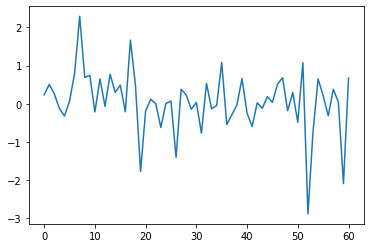

In [128]:
## Rank vs Bias
CT = "Medium spiny neuron"
CT_Idx = Anno[Anno["Supercluster"]==CT].index.values
Gene_Idx = Spark_Meta_2stage.head(61)["EntrezID"].values
dat = CT_Z2_MAT_HC.loc[Gene_Idx, CT_Idx].mean(axis=1)
plt.plot(np.arange(len(Gene_Idx)), dat,)

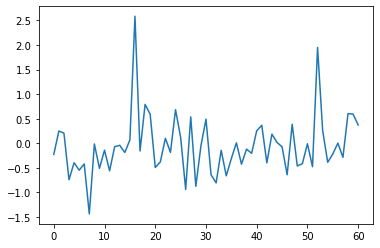

In [129]:
CT = "MGE interneuron"
CT_Idx = Anno[Anno["Supercluster"]==CT].index.values
Gene_Idx = Spark_Meta_2stage.head(61)["EntrezID"].values
dat = CT_Z2_MAT_HC.loc[Gene_Idx, CT_Idx].mean(axis=1)
plt.plot(np.arange(len(Gene_Idx)), dat,)

In [186]:
Z2Mat = pd.read_csv("../../ASD_Circuits/dat/allen-mouse-exp//AllenMouseBrain_Z2bias.csv", index_col=0)
allen_mouse_genes = Z2Mat.index.values
BGMR = pd.read_csv("~/Work/Resources/MutationRate_20170710_rate.txt", delimiter="\t")
BGMR["Entrez"] = [int(GeneSymbol2Entrez.get(x, -1)) for x in BGMR["GeneName"].values]
BGMR = BGMR[BGMR["Entrez"].isin(allen_mouse_genes)]
BGMR.index = BGMR["Entrez"].values

/tmp/ipykernel_1954016/3868777045.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  BGMR = pd.read_csv("~/Work/Resources/MutationRate_20170710_rate.txt", delimiter="\t")


In [187]:
NLGDs = []
NDmis = []
Bias_CT = {}
for i, row in Spark_Meta_2stage.head(60).iterrows():
    gene = int(row["EntrezID"])
    if gene in BGMR.index.values:
        rate1 = BGMR.loc[gene, "p_LGD"]*1e6
        rate2 = BGMR.loc[gene, "prevel_0.5"]*1e6
    else:
        rate1 = BGMR["p_LGD"].mean()*1e6
        rate2 = BGMR["prevel_0.5"].mean()*1e6
    NLGDs.append(row["AutismMerged_LoF"]/rate1)
    NDmis.append(row["AutismMerged_Dmis_REVEL0.5"]/rate2)
    for CT in Neurons:
        CT_Idx = Anno[Anno["Supercluster"]==CT].index.values
        if CT not in Bias_CT:
            Bias_CT[CT] = []
        Bias_CT[CT].append(CT_Z2_MAT_HC.loc[gene, CT_Idx].mean())
NLGDs = np.array(NLGDs)
NDmis = np.array(NDmis)

In [191]:
NLGDs = []
NDmis = []
Bias_CT = {}
for i, row in Spark_Meta_2stage.head(159).iterrows():
    gene = int(row["EntrezID"])

    NLGDs.append(row["AutismMerged_LoF"])
    NDmis.append(row["AutismMerged_Dmis_REVEL0.5"])
    for CT in Neurons:
        CT_Idx = Anno[Anno["Supercluster"]==CT].index.values
        if CT not in Bias_CT:
            Bias_CT[CT] = []
        Bias_CT[CT].append(CT_Z2_MAT_HC.loc[gene, CT_Idx].mean())
NLGDs = np.array(NLGDs)
NDmis = np.array(NDmis)

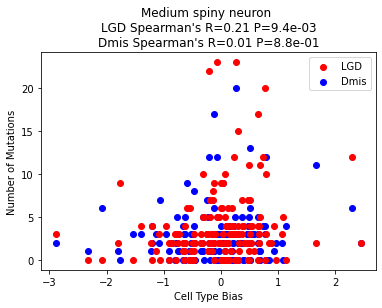

In [192]:
CT = "Medium spiny neuron"
plt.scatter(Bias_CT[CT], NLGDs, label="LGD", color="red", zorder=2)
plt.scatter(Bias_CT[CT], NDmis, label="Dmis", color="blue", zorder=1)
plt.xlabel("Cell Type Bias")
plt.ylabel("Number of Mutations")
r1, p1 = spearmanr(Bias_CT[CT], NLGDs)
r2, p2 = spearmanr(Bias_CT[CT], NDmis)
plt.title("%s \nLGD Spearman's R=%.2f P=%.1e\nDmis Spearman's R=%.2f P=%.1e"%(CT, r1, p1, r2, p2))
plt.legend()
plt.show()

Amygdala excitatory


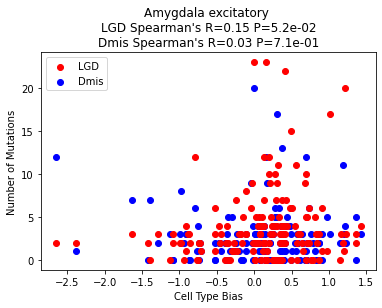

CGE interneuron


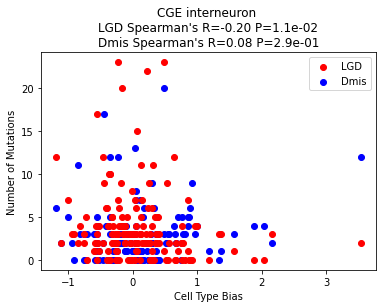

Cerebellar inhibitory


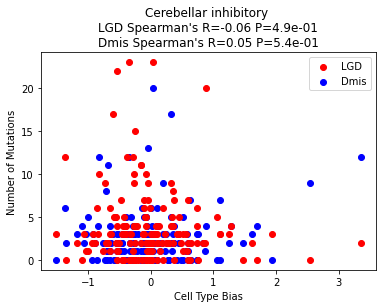

Deep-layer corticothalamic and 6b


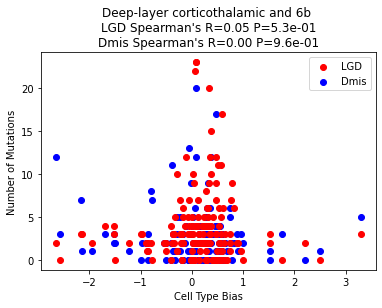

Deep-layer intratelencephalic


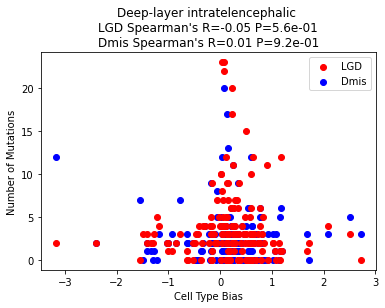

Deep-layer near-projecting


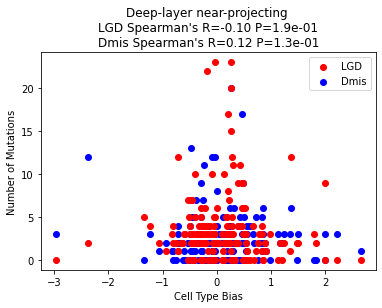

Eccentric medium spiny neuron


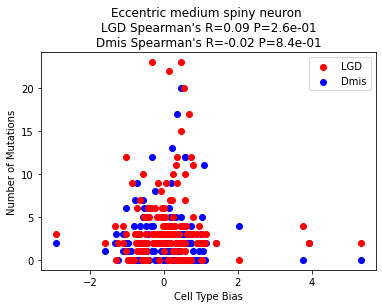

Hippocampal CA1-3


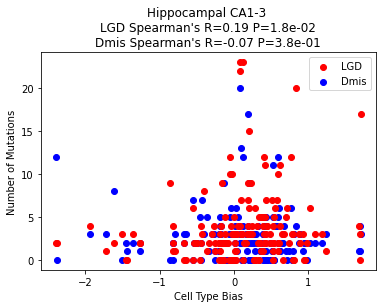

Hippocampal CA4


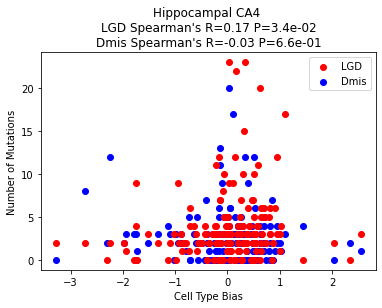

Hippocampal dentate gyrus


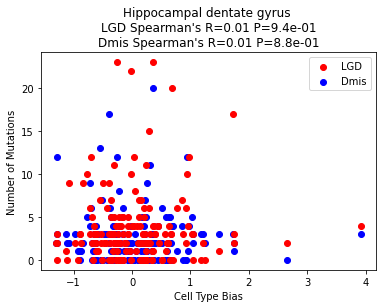

LAMP5-LHX6 and Chandelier


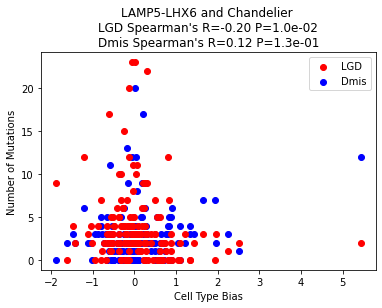

Lower rhombic lip


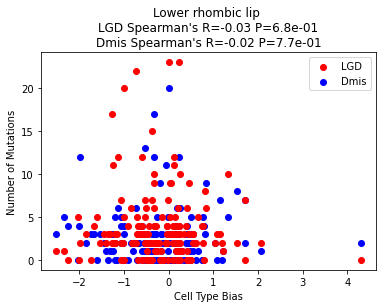

MGE interneuron


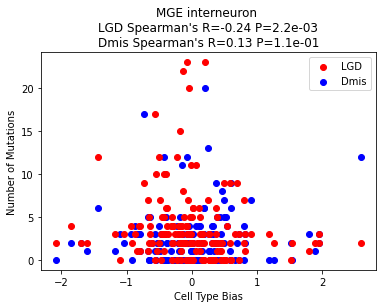

Mammillary body


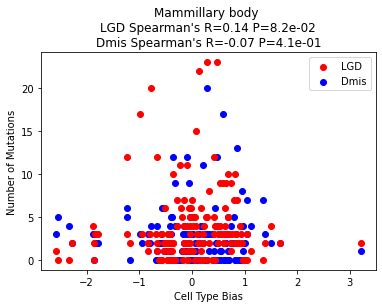

Medium spiny neuron


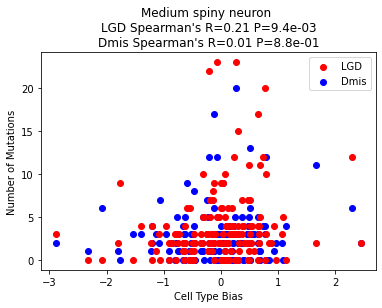

Midbrain-derived inhibitory


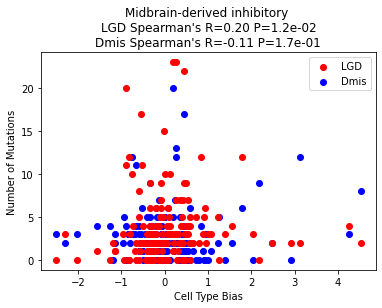

Miscellaneous


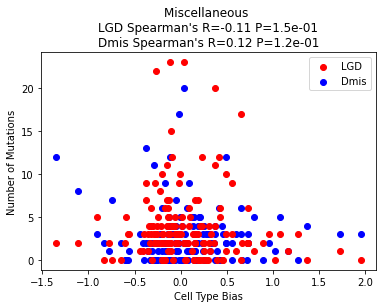

Splatter


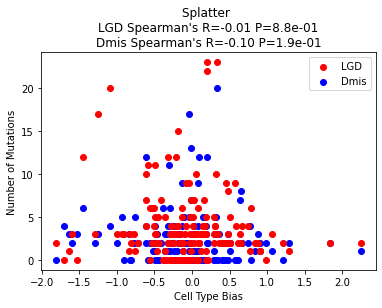

Thalamic excitatory


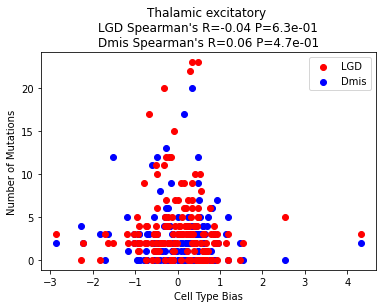

Upper rhombic lip


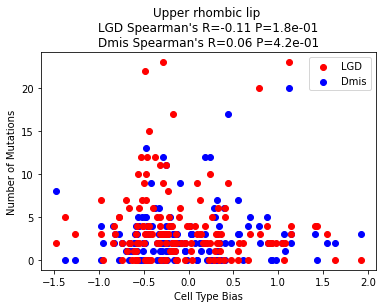

Upper-layer intratelencephalic


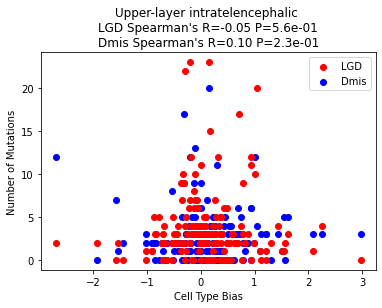

In [117]:
for CT in Neurons:
    print(CT)
    plt.scatter(Bias_CT[CT], NLGDs, label="LGD", color="red", zorder=2)
    plt.scatter(Bias_CT[CT], NDmis, label="Dmis", color="blue", zorder=1)
    plt.xlabel("Cell Type Bias")
    plt.ylabel("Number of Mutations")
    r1, p1 = spearmanr(Bias_CT[CT], NLGDs)
    r2, p2 = spearmanr(Bias_CT[CT], NDmis)
    plt.title("%s \nLGD Spearman's R=%.2f P=%.1e\nDmis Spearman's R=%.2f P=%.1e"%(CT, r1, p1, r2, p2))
    plt.legend()
    plt.show()

## High IQ vs Low IQ

In [17]:
Spark_Denovo = pd.read_excel("../dat/41588_2022_1148_MOESM4_ESM.xlsx",
                           skiprows=2, sheet_name="Table S7")
Spark_Denovo = Spark_Denovo[Spark_Denovo[
    "pDenovoWEST_Meta"]!="."]
Spark_Denovo_ExomeWide = Spark_Denovo[Spark_Denovo[
    "pDenovoWEST_Meta"]<=1.3e-6]
Spark_Denovo_ExomeWide.shape

(61, 56)

In [18]:
Mut_n_IQ = pd.read_csv("../dat/ASD_IQ_Mut.csv")
Mut_n_IQ = Mut_n_IQ[Mut_n_IQ["Entrez"].isin(HCT_Z2_MAT_HCT.index.values)]

In [19]:
top_Genes = Spark_Denovo_ExomeWide["HGNC"].values
Mut_n_IQ_conf = Mut_n_IQ[Mut_n_IQ["HGNC"].isin(top_Genes)]
Mut_n_IQ_conf.shape

(221, 11)

In [20]:
HighIQMuts_ALL = Mut_n_IQ[Mut_n_IQ["IQ"]>70]
LowIQMuts_ALL = Mut_n_IQ[Mut_n_IQ["IQ"]<=70]

HighIQMuts = Mut_n_IQ_conf[Mut_n_IQ_conf["IQ"]>70]
LowIQMuts = Mut_n_IQ_conf[Mut_n_IQ_conf["IQ"]<=70]

In [21]:
HIQ_GW = Mut2GeneDF(HighIQMuts, GeneSymbol2Entrez, pLI=False)
LIQ_GW = Mut2GeneDF(LowIQMuts, GeneSymbol2Entrez, pLI=False)
OutDIR = "../dat/GeneWeights/"
Dict2Fil(HIQ_GW, "{}/HIQ.top61.nopLI.gw".format(OutDIR))
Dict2Fil(LIQ_GW, "{}/LIQ.top61.nopLI.gw".format(OutDIR))

In [24]:
HIQ_GW = Mut2GeneDF(HighIQMuts, GeneSymbol2Entrez, pLI=False, LGD_weight_nopli=1, Dmis_weight_nopli=1)
LIQ_GW = Mut2GeneDF(LowIQMuts, GeneSymbol2Entrez, pLI=False, LGD_weight_nopli=1, Dmis_weight_nopli=1)
OutDIR = "../dat/GeneWeights/"
Dict2Fil(HIQ_GW, "{}/HIQ.top61.nopLI.LGD_Dmis_SameWeight.gw".format(OutDIR))
Dict2Fil(LIQ_GW, "{}/LIQ.top61.nopLI.LGD_Dmis_SameWeight.gw".format(OutDIR))

In [22]:
# Get genes with mutations in HighIQMuts
genes_with_mutations = set(HighIQMuts_ALL["HGNC"].unique())

# Sort Spark_Denovo by pDenovoWEST_Meta and get top genes that have mutations
top_genes = Spark_Denovo.sort_values("pDenovoWEST_Meta")[
    Spark_Denovo["HGNC"].isin(genes_with_mutations)
].head(61)

print(f"Number of top genes: {len(top_genes)}")
print("\nTop genes sorted by pDenovoWEST_Meta:")
print(top_genes[["HGNC", "pDenovoWEST_Meta"]].to_string())

Number of top genes: 61

Top genes sorted by pDenovoWEST_Meta:
       HGNC pDenovoWEST_Meta
0    DNMT3A              0.0
1      POGZ              0.0
2     SCN2A              0.0
4     MECP2              0.0
5    GIGYF1              0.0
6    SLC6A1              0.0
7    GRIN2B              0.0
8      PTEN              0.0
16     CHD8              0.0
15  SYNGAP1              0.0
10    KDM5B              0.0
12    KMT5B              0.0
11    FOXP1              0.0
9      CHD2              0.0
13   ARID1B              0.0
18   DYRK1A              0.0
19     CUL3              0.0
20      NF1              0.0
21    ASH1L              0.0
23    KDM6B              0.0
25  ANKRD11              0.0
27    MYT1L              0.0
29     RORB              0.0
30    ASXL3              0.0
34   MED13L              0.0
35    KCNQ3              0.0
39     TSC2              0.0
41     TBR1              0.0
42     TLK2              0.0
43     ANK2              0.0
44  DYNC1H1              0.0
45    KMT

/tmp/ipykernel_8804/789210819.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  top_genes = Spark_Denovo.sort_values("pDenovoWEST_Meta")[


In [23]:
top_genes

,GeneID,EntrezID,HGNC,CytoBand,ExACpLI,LoFOvsE,LOEUF,LOEUFbin,SynOvsE,sHet,...,AllExpected_Meta,pAllEnrich_Meta,MisObserved_Meta,MisExpected_Meta,pMisEnrich_Meta,MisEvents_Meta,MisDist_Meta,pMisCluster_Meta,pMisComb_Meta,pDenovoWEST_Meta
0,ENSG00000119772,1788,DNMT3A,2p23.3,0.0,1.255000,1.581,8,0.94788,0.002902,...,0.163614,0.0,2.08,0.133761,0.0,16,178,0.0,0.0,0.0
1,ENSG00000143442,23126,POGZ,1q21.3,1,0.045859,0.119,0,0.97057,0.214955,...,0.418751,0.0,0.396,0.222332,0.2,4,170.7,0.00691,0.01,0.0
2,ENSG00000136531,6326,SCN2A,2q24.3,1,0.060487,0.127,0,1.00840,0.257771,...,1.002929,0.0,8.19,0.762217,0.0,26,1325.5,0.39,0.0,0.0
4,ENSG00000169057,4204,MECP2,Xq28,0.69809,0.085755,0.407,1,2.02820,0.088203,...,0.090747,0.0,4.662,0.068396,0.0,14,156.3,0.000492,0.0,0.0
5,ENSG00000146830,64599,GIGYF1,7q22.1,0.9787,0.338960,0.484,2,1.26200,0.046573,...,0.494562,0.0,0.864,0.319525,0.06,4,994.9,0.76,0.18,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,ENSG00000153827,9320,TRIP12,2q36.3,1,0.018956,0.060,0,1.04960,0.660255,...,0.682827,0.000092,2.259,0.406826,0.00002,11,1110.3,0.12,0.000035,0.000035
88,ENSG00000119669,64207,IRF2BPL,14q24.3,0.96894,0.156750,0.405,1,1.87560,.,...,0.278758,0.000049,0.432,0.215896,0.15,2,1043,0.69,0.34,0.000049
90,ENSG00000204406,55777,MBD5,2q23.2,0.99985,0.043103,0.136,0,1.04580,0.237217,...,0.370306,0.000053,0.297,0.230942,0.39,3,1888,0.74,0.65,0.000053
93,ENSG00000170471,57148,RALGAPB,20q11.23,1,0.041206,0.106,0,1.02350,0.534301,...,0.493383,0.000073,0.099,0.331427,1,1,.,.,1,0.000073


In [62]:
(Spark_Denovo["pDenovoWEST_Meta"]<1e-3).sum()

134

# 22q11.2 

In [3]:
Gene22q = [8214, 5625, 9993, 23617, 2928, 6576, 8218, 7290, 64976, 128977,
           8318, 7122, 2812, 6899, 54584, 10587, 1312, 421, 128989, 54487,
           27037, 5902, 29801, 388849, 65078, 85359, 373856, 7625, 91179, 84861,
           51586, 5297, 3053, 9342, 1399, 150209, 8216, 80764, 9127, 6545, 400891,
           8220, 7353, 5413, 79680, 728418]
X22q_GW = dict(zip(Gene22q, [1]*len(Gene22q)))

X22q_mouse_model_genes_corrected = ["DGCR6", "PRODH", "DGCR2", "TSSK2", "ESS2", "GSC2", "SLC25A1",
                         "CLTCL1", "HIRA", "MRPL40", "UFD1", "CDC45", "CLDN5", "SEPTIN5",
                         "GP1BB", "TBX1", "GNB1L", "TXNRD2", "COMT", "ARVCF", "CD38", 
                         "DGCR8", "TRMT2A", "RANBP1", "ZDHHC8", "RTN4R", "PRODH", "DGCR6L"]
X22q_mouse_model_entrez = [GeneSymbol2Entrez[x] for x in X22q_mouse_model_genes_corrected]
X22q_V2_GW = dict(zip(X22q_mouse_model_entrez, [1]*len(X22q_mouse_model_entrez)))

Dict2Fil(X22q_GW, "../dat/GeneWeights/X22q.gw.csv")
Dict2Fil(X22q_V2_GW, "../dat/GeneWeights/X22q.mousemodel.gw.csv")


In [4]:
print(len(Gene22q), len(X22q_mouse_model_entrez))

46 28


# Bipolar

In [3]:
df = pd.read_csv("../../data/Bipolar/Bipolar_gene_res.tsv", sep="\t")
df1 = df[df["group"]=="Bipolar Disorder"]
df2 = df[df["group"]=="Bipolar Disorder (including Schizoaffective)"]
print(df.shape, df2.shape)

(119958, 20) (19993, 20)


In [4]:
# Annotate genes and combine p from dmis and PTV
for i, row in df1.iterrows():
    gene_id = row["gene_id"]
    gene_entrez = ENSID2Entrez.get(gene_id, 0)
    gene_symbol = Entrez2Symbol.get(gene_entrez, ".")
    ncase = row["n_cases"]
    ncont = row["n_controls"]
    df1.loc[i, "EntrezID"] = gene_entrez
    df1.loc[i, "Symbol"] = gene_symbol
    #print(gene_entrez, gene_symbol)
    _, fisherP = scipy.stats.combine_pvalues([row["damaging_missense_fisher_gnom_non_psych_pval"], 
                                    row["ptv_fisher_gnom_non_psych_pval"]])
    #print(fisherP)
    Eff_LGD = row["ptv_case_count"] - row["ptv_control_count"]/ncont*ncase
    Eff_Dmis = row["damaging_missense_case_count"] - row["damaging_missense_control_count"]/ncont*ncase
    df1.loc[i, "Pcombine"] = fisherP
    df1.loc[i, "Effect.LGD"] = max(0, Eff_LGD)
    df1.loc[i, "Effect.Dmis"] = max(0, Eff_Dmis)
df1 = df1.sort_values("Pcombine", ascending=True)
df1 = df1[(df1["Effect.LGD"]>0) | (df1["Effect.Dmis"]>0)]
df1["EntrezID"] = [int(x) for x in df1["EntrezID"].values]
df1.to_csv("../dat/bipolar.genes.modified.csv")

/tmp/ipykernel_76362/4217726819.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.loc[i, "EntrezID"] = gene_entrez
/tmp/ipykernel_76362/4217726819.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.loc[i, "Symbol"] = gene_symbol
/tmp/ipykernel_76362/4217726819.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/u

In [5]:
# Annotate genes and combine p from dmis and PTV
for i, row in df2.iterrows():
    gene_id = row["gene_id"]
    gene_entrez = ENSID2Entrez.get(gene_id, 0)
    gene_symbol = Entrez2Symbol.get(gene_entrez, ".")
    ncase = row["n_cases"]
    ncont = row["n_controls"]
    df2.loc[i, "EntrezID"] = gene_entrez
    df2.loc[i, "Symbol"] = gene_symbol
    #print(gene_entrez, gene_symbol)
    _, fisherP = scipy.stats.combine_pvalues([row["damaging_missense_fisher_gnom_non_psych_pval"], 
                                    row["ptv_fisher_gnom_non_psych_pval"]])
    #print(fisherP)
    Eff_LGD = row["ptv_case_count"] - row["ptv_control_count"]/ncont*ncase
    Eff_Dmis = row["damaging_missense_case_count"] - row["damaging_missense_control_count"]/ncont*ncase
    df2.loc[i, "Pcombine"] = fisherP
    df2.loc[i, "Effect.LGD"] = max(0, Eff_LGD)
    df2.loc[i, "Effect.Dmis"] = max(0, Eff_Dmis)
df2 = df2.sort_values("Pcombine", ascending=True)
df2 = df2[(df2["Effect.LGD"]>0) | (df2["Effect.Dmis"]>0)]
df2["EntrezID"] = [int(x) for x in df2["EntrezID"].values]
df2.to_csv("../dat/bipolar.wscz.genes.modified.csv")

/tmp/ipykernel_76362/980332554.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.loc[i, "EntrezID"] = gene_entrez
/tmp/ipykernel_76362/980332554.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.loc[i, "Symbol"] = gene_symbol
/tmp/ipykernel_76362/980332554.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user

In [6]:
BP_topG = df2.head(61)["Symbol"].values
BP_top100G = df2.head(100)["Symbol"].values
BP_top200G = df2.head(200)["Symbol"].values

In [71]:
BP_topG

array(['AKAP11', 'DOP1A', 'THSD7A', 'PAMR1', 'NBPF14', 'SYDE2', 'KDM5B',
       'PLPPR3', 'AXIN1', 'TICRR', 'NPHP3', 'BBS9', 'FRMPD2', 'ATP9A',
       'PDLIM3', 'IL16', 'SHANK1', 'PNKP', 'CYP2A13', 'SLC10A6', 'TOPAZ1',
       'NTN4', 'MINDY4B', 'POLR3GL', 'CHST13', 'PROM2', 'LOXL4', 'CHRNB2',
       'TMEM235', 'HDGFL2', 'PANX2', 'ALG10', 'ZNF736', 'TET2', 'ARHGAP5',
       'ATP2C1', 'DNAI4', 'SORCS1', 'NEK1', 'HHIPL1', 'COMTD1', 'HECTD2',
       'GPRC5A', 'ALOX15', 'RFX8', 'KRTAP10-5', 'CHD1L', 'AEBP1',
       'KLHL33', 'PTCH2', 'FOLH1', 'CCNE2', 'EIF3A', 'GIGYF1', 'TNIK',
       'ABHD11', 'BTBD16', 'ZNF786', 'TMPRSS3', 'GDF9', 'RGPD8'],
      dtype=object)

In [67]:
ASD_SCZ_DF = pd.read_csv("GeneFuncs_ASD_SCZ-NetBag.tsv", sep="\t")

In [73]:
SCZ_Symbols = ASD_SCZ_DF[ASD_SCZ_DF["SCZ"]==1]["Gene"].values
ASD_Symbols = ASD_SCZ_DF[ASD_SCZ_DF["ASD"]==1]["Gene"].values

In [74]:
set(SCZ_Symbols).intersection(set(BP_topG))

{'AKAP11', 'ATP9A'}

In [75]:
set(ASD_Symbols).intersection(set(BP_topG))

{'GIGYF1', 'KDM5B'}

In [81]:
BP_topG

array(['ABHD11', 'AEBP1', 'AKAP11', 'ALG10', 'ALOX15', 'ARHGAP5',
       'ATP2C1', 'ATP9A', 'AXIN1', 'BBS9', 'BTBD16', 'CCNE2', 'CHD1L',
       'CHRNB2', 'CHST13', 'COMTD1', 'CYP2A13', 'DNAI4', 'DOP1A', 'EIF3A',
       'FOLH1', 'FRMPD2', 'GDF9', 'GIGYF1', 'GPRC5A', 'HDGFL2', 'HECTD2',
       'HHIPL1', 'IL16', 'KDM5B', 'KLHL33', 'KRTAP10-5', 'LOXL4',
       'MINDY4B', 'NBPF14', 'NEK1', 'NPHP3', 'NTN4', 'PAMR1', 'PANX2',
       'PDLIM3', 'PLPPR3', 'PNKP', 'POLR3GL', 'PROM2', 'PTCH2', 'RFX8',
       'RGPD8', 'SHANK1', 'SLC10A6', 'SORCS1', 'SYDE2', 'TET2', 'THSD7A',
       'TICRR', 'TMEM235', 'TMPRSS3', 'TNIK', 'TOPAZ1', 'ZNF736',
       'ZNF786'], dtype=object)

In [8]:
CT_Z2_MAT_HC = pd.read_csv("../dat/HumanCellType.AllCell.HCT.Z2bias.entrez.csv", index_col=0)
CT_Z2_MAT_HC.columns = [int(x) for x in CT_Z2_MAT_HC.columns.values]

In [9]:
Bipolar_GW1 = Aggregate_Gene_Weights_Bipolar(df1.head(61), CT_Z2_MAT_HC.index.values)
Bipolar_GW2 = Aggregate_Gene_Weights_Bipolar(df2.head(61), CT_Z2_MAT_HC.index.values)

Bipolar_100GW = Aggregate_Gene_Weights_Bipolar(df1.head(100), CT_Z2_MAT_HC.index.values)
Bipolar_200GW2 = Aggregate_Gene_Weights_Bipolar(df1.head(200), CT_Z2_MAT_HC.index.values)

79819 not in allen mouse dataset
79819 not in allen mouse dataset
79819 not in allen mouse dataset
642517 not in allen mouse dataset
79819 not in allen mouse dataset
642517 not in allen mouse dataset
0 not in allen mouse dataset
0 not in allen mouse dataset


In [10]:
Dict2Fil(Bipolar_GW1, "../dat/Bipolar.top61.gw.csv")
Dict2Fil(Bipolar_GW2, "../dat/Bipolar.2.top61.gw.csv")
Dict2Fil(Bipolar_100GW, "../dat/Bipolar.top100.gw.csv")
Dict2Fil(Bipolar_200GW2, "../dat/Bipolar.top200.gw.csv")

# NDD

In [46]:
df = pd.read_excel("/home/jw3514/Work/data/DDD/41586_2020_2832_MOESM4_ESM.xlsx")
df = df.sort_values("denovoWEST_p_full")
hc_df = df[df["denovoWEST_p_full"]<=0.05/18762]
entrez_ids = [int(GeneSymbol2Entrez.get(x, -1)) for x in hc_df["symbol"].values]
hc_df["EntrezID"] = entrez_ids
hc_df.shape

/tmp/ipykernel_1073400/2557357663.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hc_df["EntrezID"] = entrez_ids


(297, 35)

In [52]:

#DDD_hc_GW = dict(zip(DDD_hc_entrez, [1]*len(DDD_hc_entrez)))
DDD_hc_GW = Aggregate_Gene_Weights_NDD(hc_df, out="../dat/GeneWeights/DDD.hc.gw.csv")
NDD_top61_DF = hc_df.head(61)
DDD_top61_GW = Aggregate_Gene_Weights_NDD(NDD_top61_DF, out="../dat/GeneWeights/DDD.top61.gw.csv")
#Dict2Fil(DDD_top61_GW, "../dat/GeneWeights/DDD.top61.gw.csv")



# Epi25

In [79]:
Epi25DF = pd.read_excel("../../data/Epilepsy/1-s2.0-S0002929721001403-mmc2.xlsx", 
                        sheet_name="S17 All Epi Deleterious")

In [80]:
#Epi25DF.columns.values

In [81]:
# 'Missense.Case', 'PTV.Case', 'Missense.Ctrl', 'PTV.Ctrl'

In [82]:
Epi25DF = Epi25DF[Epi25DF["estimate"]>1]
for i, row in Epi25DF.iterrows():
    symbol = Epi25DF.loc[i, "gene"].strip("''")
    Epi25DF.loc[i, "gene"] = symbol
    try:
        Epi25DF.loc[i, "Entrez"] = int(GeneSymbol2Entrez[symbol])
    except:
        Epi25DF.loc[i, "Entrez"] = None
    try:
        Epi25DF.loc[i, "pLI"] = ExAC_pLI.loc[symbol, "pLI"]
    except:
        Epi25DF.loc[i, "pLI"] = 0
    Epi25DF.loc[i, "nLGD"] = ModifyMutCount(Epi25DF.loc[i, "PTV.Case"], 
                                    Epi25DF.loc[i, "PTV.Ctrl"], 0, CaseN=13487, ContN=15678) 
    Epi25DF.loc[i, "nMis"] = ModifyMutCount(Epi25DF.loc[i, "Missense.Case"], 
                                    Epi25DF.loc[i, "Missense.Ctrl"], 0, CaseN=13487, ContN=15678) 
    
Epi25DF = Epi25DF.dropna(subset="Entrez")
Epi25DF_Filt = Epi25DF[["gene", "Entrez", "pLI", "nLGD", "nMis"]]
Epi25DF_Filt["Entrez"] = [int(x) for x in Epi25DF_Filt["Entrez"].values]
Epi25DF_Filt = Epi25DF_Filt.set_index("Entrez")
Epi25DF_Filt.shape

/tmp/ipykernel_76362/3599274987.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Epi25DF_Filt["Entrez"] = [int(x) for x in Epi25DF_Filt["Entrez"].values]


(79, 4)

In [83]:
Epi25DF_Filt.head(10)

,gene,pLI,nLGD,nMis
Entrez,,,,
6323,SCN1A,0.0,14.00000,45.214249
2903,GRIN2A,0.0,13.00000,10.139750
9681,DEPDC5,0.0,30.69875,0.000000
164781,DAW1,0.0,3.13975,10.000000
6529,SLC6A1,0.0,1.00000,16.279500
1101,CHAD,0.0,5.00000,3.000000
4928,NUP98,0.0,1.00000,9.419250
6334,SCN8A,0.0,4.00000,21.074499
57582,KCNT1,0.0,0.00000,21.419250


In [88]:
Epi25_GW = Aggregate_Gene_Weights_Epi25(Epi25DF_Filt, ExpZ2Mat.index.values)

1071 not in allen mouse dataset
389396 not in allen mouse dataset
84953 not in allen mouse dataset
30837 not in allen mouse dataset


In [90]:
Dict2Fil(Epi25_GW, "../dat3/Epi25.gw.csv")

In [95]:
Epi25DF = pd.read_excel("../../data/Epilepsy/1-s2.0-S0002929721001403-mmc2.xlsx", 
                        sheet_name="S17 All Epi Deleterious")
Epi25DF_Neg = Epi25DF[Epi25DF["estimate"]<1]
for i, row in Epi25DF_Neg.iterrows():
    symbol = Epi25DF_Neg.loc[i, "gene"].strip("''")
    Epi25DF_Neg.loc[i, "gene"] = symbol
    try:
        Epi25DF_Neg.loc[i, "Entrez"] = int(GeneSymbol2Entrez[symbol])
    except:
        Epi25DF_Neg.loc[i, "Entrez"] = None
    try:
        Epi25DF_Neg.loc[i, "pLI"] = ExAC_pLI.loc[symbol, "pLI"]
    except:
        Epi25DF_Neg.loc[i, "pLI"] = 0
    Epi25DF_Neg.loc[i, "nLGD"] = ModifyMutCount(Epi25DF_Neg.loc[i, "PTV.Case"], 
                                    Epi25DF.loc[i, "PTV.Ctrl"], -1000, CaseN=13487, ContN=15678) 
    Epi25DF_Neg.loc[i, "nMis"] = ModifyMutCount(Epi25DF_Neg.loc[i, "Missense.Case"], 
                                    Epi25DF.loc[i, "Missense.Ctrl"], -1000, CaseN=13487, ContN=15678) 
    
Epi25DF_Neg = Epi25DF_Neg.dropna(subset="Entrez")
Epi25DF_Neg_Filt = Epi25DF_Neg[["gene", "Entrez", "pLI", "nLGD", "nMis"]]
Epi25DF_Neg_Filt["Entrez"] = [int(x) for x in Epi25DF_Neg_Filt["Entrez"].values]
Epi25DF_Neg_Filt = Epi25DF_Neg_Filt.set_index("Entrez")
Epi25DF_Neg_Filt.shape

/tmp/ipykernel_76362/3672646954.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Epi25DF_Neg.loc[i, "Entrez"] = int(GeneSymbol2Entrez[symbol])
/tmp/ipykernel_76362/3672646954.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Epi25DF_Neg.loc[i, "pLI"] = 0
/tmp/ipykernel_76362/3672646954.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org

(113, 4)

In [97]:
Epi25DF_Neg_Filt

,gene,pLI,nLGD,nMis
Entrez,,,,
6647,SOD1,0.0,0.0,0.0
374291,NDUFS7,0.0,0.0,0.0
956,ENTPD3,0.0,0.0,0.0
387496,RASL11A,0.0,0.0,0.0
56265,CPXM1,0.0,0.0,0.0
...,...,...,...,...
51703,ACSL5,0.0,0.0,0.0
136332,LRGUK,0.0,0.0,0.0
51154,MRTO4,0.0,0.0,0.0


In [101]:
Epi25DF_Protect_gw = dict(zip(Epi25DF_Neg_Filt.index.values, [1]*len(Epi25DF_Neg_Filt.index.values)))
Dict2Fil(Epi25DF_Protect_gw, "../dat3/Epi25.protect.gw.csv")

In [99]:
Epi25DF_Protect_gw

{6647: 1,
 374291: 1,
 956: 1,
 387496: 1,
 56265: 1,
 4040: 1,
 9904: 1,
 25981: 1,
 6915: 1,
 2956: 1,
 11254: 1,
 7769: 1,
 641: 1,
 9943: 1,
 346562: 1,
 2676: 1,
 57089: 1,
 143570: 1,
 374354: 1,
 219293: 1,
 196528: 1,
 146456: 1,
 10585: 1,
 57172: 1,
 8714: 1,
 84976: 1,
 57134: 1,
 27243: 1,
 55293: 1,
 1103: 1,
 1629: 1,
 1788: 1,
 26509: 1,
 713: 1,
 5339: 1,
 4319: 1,
 79258: 1,
 401548: 1,
 9014: 1,
 4669: 1,
 56987: 1,
 8784: 1,
 26156: 1,
 4750: 1,
 80821: 1,
 2271: 1,
 1134: 1,
 6331: 1,
 55663: 1,
 6608: 1,
 341676: 1,
 25870: 1,
 134510: 1,
 1286: 1,
 2147: 1,
 9457: 1,
 51702: 1,
 91662: 1,
 9118: 1,
 51067: 1,
 81796: 1,
 8493: 1,
 4626: 1,
 124590: 1,
 23683: 1,
 7481: 1,
 170384: 1,
 55803: 1,
 8569: 1,
 5253: 1,
 56999: 1,
 9705: 1,
 375337: 1,
 54790: 1,
 780: 1,
 10072: 1,
 6461: 1,
 55971: 1,
 53: 1,
 339327: 1,
 8854: 1,
 9704: 1,
 6469: 1,
 2110: 1,
 140706: 1,
 8633: 1,
 7046: 1,
 11262: 1,
 5834: 1,
 79411: 1,
 24141: 1,
 200879: 1,
 8483: 1,
 125115: 1,


#### subtypes

In [102]:
DEE_DF = pd.read_excel("../../data/Epilepsy/1-s2.0-S0002929721001403-mmc2.xlsx", 
                        sheet_name="S09 DEE Deleterious")
GGE_DF = pd.read_excel("../../data/Epilepsy/1-s2.0-S0002929721001403-mmc2.xlsx", 
                        sheet_name="S12 GGE Deleterious")
NAFE_DF = pd.read_excel("../../data/Epilepsy/1-s2.0-S0002929721001403-mmc2.xlsx", 
                        sheet_name="S14 NAFE Deleterious")

In [105]:
def Filt_Epilepsy_DF(Epi25DF, Ncase, Ncontrol):
    Epi25DF = Epi25DF[Epi25DF["estimate"]>1]
    for i, row in Epi25DF.iterrows():
        symbol = Epi25DF.loc[i, "gene"].strip("''")
        Epi25DF.loc[i, "gene"] = symbol
        try:
            Epi25DF.loc[i, "Entrez"] = int(GeneSymbol2Entrez[symbol])
        except:
            Epi25DF.loc[i, "Entrez"] = None
        try:
            Epi25DF.loc[i, "pLI"] = ExAC_pLI.loc[symbol, "pLI"]
        except:
            Epi25DF.loc[i, "pLI"] = 0
        Epi25DF.loc[i, "nLGD"] = ModifyMutCount(Epi25DF.loc[i, "PTV.Case"], 
                                        Epi25DF.loc[i, "PTV.Ctrl"], 0, CaseN=Ncase, ContN=Ncontrol) 
        Epi25DF.loc[i, "nMis"] = ModifyMutCount(Epi25DF.loc[i, "Missense.Case"], 
                                        Epi25DF.loc[i, "Missense.Ctrl"], 0, CaseN=Ncase, ContN=Ncontrol) 

    Epi25DF = Epi25DF.dropna(subset="Entrez")
    Epi25DF_Filt = Epi25DF[["gene", "Entrez", "pLI", "nLGD", "nMis"]]
    Epi25DF_Filt["Entrez"] = [int(x) for x in Epi25DF_Filt["Entrez"].values]
    Epi25DF_Filt = Epi25DF_Filt.set_index("Entrez")
    return Epi25DF_Filt

In [106]:
DEE_DF_Filt = Filt_Epilepsy_DF(DEE_DF, 1835, 13978)
GEE_DF_Filt = Filt_Epilepsy_DF(GGE_DF, 5303, 15677)
NAFE_DF_Filt = Filt_Epilepsy_DF(NAFE_DF, 6439, 15678)

/tmp/ipykernel_76362/1721047433.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Epi25DF.loc[i, "Entrez"] = int(GeneSymbol2Entrez[symbol])
/tmp/ipykernel_76362/1721047433.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Epi25DF.loc[i, "pLI"] = 0
/tmp/ipykernel_76362/1721047433.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-

In [113]:
DEE_GW = Aggregate_Gene_Weights_Epi25(DEE_DF_Filt, ExpZ2Mat.index.values)
Dict2Fil(DEE_GW, "../dat3/Epi25.DEE.gw.csv")

GEE_GW = Aggregate_Gene_Weights_Epi25(GEE_DF_Filt, ExpZ2Mat.index.values)
Dict2Fil(GEE_GW, "../dat3/Epi25.GEE.gw.csv")

NAFE_GW = Aggregate_Gene_Weights_Epi25(NAFE_DF_Filt, ExpZ2Mat.index.values)
Dict2Fil(NAFE_GW, "../dat3/Epi25.NAFE.gw.csv")

55556 not in allen mouse dataset
284370 not in allen mouse dataset
80139 not in allen mouse dataset
201456 not in allen mouse dataset
9668 not in allen mouse dataset
127795 not in allen mouse dataset
653583 not in allen mouse dataset
55616 not in allen mouse dataset
84953 not in allen mouse dataset
101060200 not in allen mouse dataset
51513 not in allen mouse dataset
389396 not in allen mouse dataset
219453 not in allen mouse dataset
440107 not in allen mouse dataset
412 not in allen mouse dataset
1071 not in allen mouse dataset
391211 not in allen mouse dataset
30837 not in allen mouse dataset
388960 not in allen mouse dataset
348094 not in allen mouse dataset
6975 not in allen mouse dataset
1760 not in allen mouse dataset
387778 not in allen mouse dataset
91151 not in allen mouse dataset
26290 not in allen mouse dataset
1117 not in allen mouse dataset
440956 not in allen mouse dataset
828 not in allen mouse dataset


In [111]:
DEE_GW

{6323: 1.2943611389326084,
 112755: 0.44,
 6792: 0.4173744455573043,
 57582: 0.152123336671913,
 6812: 0.5547488911146087,
 4204: 0.45111890113034764,
 10239: 0.364246673343826,
 2903: 0.2973744455573043,
 9681: 0.645480040062956,
 64333: 0.5858677922449563,
 2554: 0.132123336671913,
 6334: 0.24223780226069536,
 8831: 0.6,
 1101: 0.16,
 11152: 0.6,
 8243: 0.3747488911146087,
 123099: 0.17474889111460867,
 4763: 0.21235226784947775,
 115795: 0.24,
 10847: 0.10061668335956503,
 55191: 0.2901144655887824,
 125: 0.34424667334382597,
 79603: 0.5153655744741736,
 56253: 0.244246673343826,
 79633: 0.13698669337530406,
 350: 0.11374445557304336,
 527: 0.04,
 151050: 0.76123336671913,
 6096: 0.152123336671913,
 2904: 0.06949778222921735,
 7324: 0.24,
 58484: 0.328493346687652,
 26276: 0.2589955644584347,
 6017: 0.07899556445843468,
 29123: 0.36,
 4607: 0.14347116897982543,
 7025: 0.27474889111460865,
 11245: 0.13999999999999999,
 4863: 0.48,
 79581: 0.2458677922449564,
 23254: 0.057374445557304

In [112]:
GEE_GW

{6529: 0.3864693500031894,
 6323: 0.824101550041462,
 54455: 0.5464693500031894,
 164781: 0.17940805000956817,
 2903: 0.3332346750015947,
 4928: 0.23293870000637878,
 2554: 0.5723467500159469,
 338567: 0.32,
 388569: 0.36,
 55732: 0.62,
 2863: 0.27999999999999997,
 54825: 0.8164483000574089,
 79665: 0.38,
 29123: 0.48,
 2701: 0.30646935000318937,
 11277: 0.1729387000063788,
 241: 0.06,
 140803: 0.8243975250366778,
 25885: 0.29881610001913633,
 1821: 0.49970402500478406,
 9162: 0.41323467500159466,
 1460: 0.18,
 57510: 0.4197040250047841,
 6096: 0.25970402500478407,
 30010: 0.16,
 23152: 0.45940805000956814,
 80070: 0.7467232251068443,
 54542: 0.5197040250047841,
 57683: 0.24,
 6004: 0.26,
 1814: 0.5064693500031894,
 2566: 0.29264272501116284,
 55205: 0.5926427250111629,
 3069: 0.6394080500095681,
 84691: 0.36,
 7738: 0.26,
 122773: 0.1932346750015947,
 9625: 0.4058774000127575,
 55790: 0.18587740001275754,
 220929: 0.6132346750015947,
 2561: 0.09970402500478408,
 57555: 0.36,
 55907: 0

# UKBB Cog function

Paper: https://www.nature.com/articles/s41588-023-01398-8

educational attainment (EDU); 

reaction time (RT); 

verbal-numerical reasoning (VNR)

In [56]:
CogDF = pd.read_excel("../dat/41588_2023_1398_MOESM3_ESM.xlsx", sheet_name="Table S4")
CogDF = CogDF[CogDF["POPULATION"]=="EUR"]

In [57]:
def DF2GW_UKBB(DF, Ncarrier=False):
    res = {}
    for i, row in DF.iterrows():
        entrez = int(GeneSymbol2Entrez.get(row["GENE"], 0))
        if entrez == 0 :
            continue
        if Ncarrier:
            res[entrez] = abs(row["BETA"]) * row["NCARRIER"]
        else:
            res[entrez] = abs(row["BETA"]) 
    return res

In [59]:
topN = 61
VNR_DF = CogDF[CogDF["PHENOTYPE"]=="VNR"].sort_values("P")
VNR_Pos_DF = VNR_DF[VNR_DF["BETA"]>0].head(topN)
VNR_Neg_DF = VNR_DF[VNR_DF["BETA"]<0].head(topN)

VNR_Pos_GW = DF2GW_UKBB(VNR_Pos_DF)
VNR_Neg_GW = DF2GW_UKBB(VNR_Neg_DF)
Dict2Fil(VNR_Pos_GW, "{}/UKBB_VNR_Pos_GW_{}.csv".format(OutDIR, topN))
Dict2Fil(VNR_Neg_GW, "{}/UKBB_VNR_Neg_GW_{}.csv".format(OutDIR, topN))

EDU_DF = CogDF[CogDF["PHENOTYPE"]=="EDU"].sort_values("P")
EDU_Pos_DF = EDU_DF[EDU_DF["BETA"]>0].head(topN)
EDU_Neg_DF = EDU_DF[EDU_DF["BETA"]<0].head(topN)

EDU_Pos_GW = DF2GW_UKBB(EDU_Pos_DF)
EDU_Neg_GW = DF2GW_UKBB(EDU_Neg_DF)
Dict2Fil(EDU_Pos_GW, "{}/UKBB_EDU_Pos_GW_{}.csv".format(OutDIR, topN))
Dict2Fil(EDU_Neg_GW, "{}/UKBB_EDU_Neg_GW_{}.csv".format(OutDIR, topN))

RT_DF = CogDF[CogDF["PHENOTYPE"]=="RT"].sort_values("P")
RT_Pos_DF = RT_DF[RT_DF["BETA"]>0].head(topN)
RT_Neg_DF = RT_DF[RT_DF["BETA"]<0].head(topN)

RT_Pos_GW = DF2GW_UKBB(RT_Pos_DF)
RT_Neg_GW = DF2GW_UKBB(RT_Neg_DF)
Dict2Fil(RT_Pos_GW, "{}/UKBB_RT_Pos_GW_{}.csv".format(OutDIR, topN))
Dict2Fil(RT_Neg_GW, "{}/UKBB_RT_Neg_GW_{}.csv".format(OutDIR, topN))

In [77]:
VNR_NoEff_DF = VNR_DF.tail(61)
VNR_NoEff_GW = DF2GW_UKBB(VNR_NoEff_DF)
Dict2Fil(VNR_NoEff_GW, "{}/UKBB_VNR_NoEff_GW_{}.csv".format(OutDIR, topN))

In [79]:
for k, v in VNR_NoEff_GW.items():
    print(Entrez2Symbol[k])

GOLGA7B
PLEC
CAMKMT
HYI
CPT2
NCOA1
IL11RA
IL4I1
LGALS4
RWDD2B
EMID1
HEATR3
PSEN1
SMARCA1
SSX4
LPCAT1
ACBD5
ESPN
HK1
ADAMTS18
GPRASP2
OCM
MORN1
EIPR1
TMCO6
DIS3
PLA2G4D
SLA
ADTRP
SYNE3
CEP55
CHRNA9
GZMB
SECISBP2
COLGALT1
MECR
TYW5
GAS7
NPHS1
CYP11B1
PDZD4
HECTD3
PDXDC1
RFX8
SWT1
MFSD13A
SLC22A9
NEMP1
CASD1
SYT15
CRNKL1
FBLN7
KLK15
LANCL1
ZNF799
ERCC1
SSC5D
BNC2
CTSB
